# peak 分布随环境噪声的演化（工作名 `peak_vs_noise`，v01）

## 要回答的问题

> **给定固定的信号强度，环境噪声逐渐增强时，信号峰值 peak 的分布怎么变？是线性变化吗？**

## 名词与口径（与 `PoD_esti` 全项目一致）

- **noise**：宏像元（macro pixel，9×3 = 27 个 SPAD）在 **1 ns 直方图 bin** 上的**平均累加计数**。
  它是本工作的横轴，由环境光谱辐照度 `E_lambda` 经 `r_det_for_noise()` 精确反解得到。
- **peak**：单次测量中，信号窗内宏像元直方图的**最大 bin 计数**（无量纲，单位＝计数）。
- **SPAD**（Single-Photon Avalanche Diode，单光子雪崩二极管）：探测器单元。
- **二值采样（binary sampling）**：每个 SPAD 在每个 bin 内**最多贡献 1 个计数**，
  因此 peak 存在**硬上限** `n_tr = 27 × N_shots`（N_shots=1 → 27，N_shots=4 → 108）。
  这个硬上限是后面一切非线性的根源之一。
- **boost**：信号强度倍率，单脉冲能量 = `boost × E_PULSE_BASE`（`E_PULSE_BASE` = 799.4 nJ）。
- **FAR**（False Alarm Rate，虚警率）：阈值 T 的选取依据，阈值曲线取自 `PoD_esti_v05` 的噪声 MC。

## 本 notebook 的数据来源

`peak_vs_noise_v01_cache.npz`，由 `peak_vs_noise_scan.py` 用 20 进程扫描生成：

- N_shots = 1：noise = 0.25 → 12.0，步长 0.25，共 48 档
- N_shots = 4：noise = 0.25 → 40.0，步长 0.25，共 160 档
- 每档 5 个固定信号强度 × 8000 条 Monte Carlo（蒙特卡洛）
- 外加 **noise = 0（无噪声纯信号）**参考档，用于可加性检验
- 缓存里存的是 peak 的 `bincount`（**完整分布的充分统计量**），不是原始样本，
  所以整个扫描只占约 1 MB，却能事后算任意分位数。

若缓存不存在，请先在仓库根目录执行：

```powershell
$env:PYTHONIOENCODING="utf-8"
python peak_vs_noise_scan.py
```

In [1]:
import os
os.environ["POD_CORE_QUIET"] = "1"      # 静音内核 import 期间的日志
import numpy as np
import matplotlib.pyplot as plt
import pod_esti_v05_core as core        # 只为拿 E_PULSE_BASE / FAR 标签 / 字体设置

CACHE = "peak_vs_noise_v01_cache.npz"
if not os.path.exists(CACHE):
    raise FileNotFoundError(
        f"缺少 {CACHE}，请先执行：python peak_vs_noise_scan.py")

_z = np.load(CACHE, allow_pickle=True)
BOOSTS   = np.asarray(_z["boosts"], float)
N_MC     = int(_z["n_mc"])
FAR_TAGS = [str(t) for t in _z["far_tags"]]
E_BASE   = core.E_PULSE_BASE            # 799.4 nJ
E_NJ     = BOOSTS * E_BASE * 1e9        # 各信号档的单脉冲能量 [nJ]
N_LIST   = [1, 4]

DATA = {}
for n in N_LIST:
    DATA[n] = {
        "noise":    np.asarray(_z[f"noise_{n}"], float),    # 目标 noise（横轴）
        "noise_mc": np.asarray(_z[f"noisemc_{n}"], float),  # MC 实测 noise
        "cnt":      np.asarray(_z[f"cnt_{n}"]),   # (n_boost, n_noise, n_tr+2)
        "cnt0":     np.asarray(_z[f"cnt0_{n}"]),  # (n_boost, n_tr+2) —— noise=0
        "done":     np.asarray(_z[f"done_{n}"], bool),
        "T":        np.asarray(_z[f"T_{n}"]),     # (n_far, n_noise) FAR 阈值
        "n_tr":     27 * n,
    }
    if not DATA[n]["done"].all():
        print(f"⚠ N_shots={n}：{(~DATA[n]['done']).sum()} / "
              f"{len(DATA[n]['done'])} 档尚未算完（缓存可能是检查点）")


# ---------------- 由 bincount 直接算统计量（无需原始样本） ----------------
def bc_mean_std(cnt):
    '''cnt 最后一维是 peak 取值；返回 (均值, 标准差)，支持任意前置维度。'''
    v = np.arange(cnt.shape[-1], dtype=float)
    n = cnt.sum(-1).astype(float)
    n = np.where(n == 0, np.nan, n)
    mean = (cnt * v).sum(-1) / n
    m2   = (cnt * v * v).sum(-1) / n
    return mean, np.sqrt(np.maximum(m2 - mean**2, 0.0))


def bc_quantile(cnt, q):
    '''在累积分布上线性插值的分位数，避免整数 peak 造成的阶梯。'''
    c = np.asarray(cnt, float)
    n = c.sum()
    if n <= 0:
        return np.nan
    cdf = np.cumsum(c) / n
    i = int(np.searchsorted(cdf, q))
    i = min(i, c.size - 1)
    lo = cdf[i - 1] if i > 0 else 0.0
    frac = (q - lo) / max(cdf[i] - lo, 1e-12)
    return i - 0.5 + float(np.clip(frac, 0.0, 1.0))


def bc_pmf(cnt):
    c = np.asarray(cnt, float)
    return c / max(c.sum(), 1.0)


# 预先算好所有档的均值 / 标准差
STAT = {}
for n in N_LIST:
    m, s = bc_mean_std(DATA[n]["cnt"])       # (n_boost, n_noise)
    m0, s0 = bc_mean_std(DATA[n]["cnt0"])    # (n_boost,) —— noise = 0
    STAT[n] = {"mean": m, "std": s, "mean0": m0, "std0": s0}

print(f"缓存载入完成：每档 {N_MC:,} 条 MC")
print(f"信号强度档 boost = {list(np.round(BOOSTS, 4))}")
print(f"          即 E = {list(np.round(E_NJ, 2))} nJ（第 0 档为纯噪声基线）")
for n in N_LIST:
    d = DATA[n]
    print(f"N_shots={n}: noise {d['noise'][0]:.2f} → {d['noise'][-1]:.2f}"
          f"（{len(d['noise'])} 档），二值硬上限 n_tr = {d['n_tr']}")
    print(f"   无噪声(noise=0)时各档 peak 均值 = "
          f"{np.round(STAT[n]['mean0'], 2)}")

缓存载入完成：每档 8,000 条 MC
信号强度档 boost = [np.float64(0.0), np.float64(0.004), np.float64(0.008), np.float64(0.016), np.float64(0.032)]
          即 E = [np.float64(0.0), np.float64(3.2), np.float64(6.4), np.float64(12.79), np.float64(25.58)] nJ（第 0 档为纯噪声基线）
N_shots=1: noise 0.25 → 12.00（48 档），二值硬上限 n_tr = 27
   无噪声(noise=0)时各档 peak 均值 = [ 0.    2.32  4.25  7.14 10.68]
N_shots=4: noise 0.25 → 40.00（160 档），二值硬上限 n_tr = 108
   无噪声(noise=0)时各档 peak 均值 = [ 0.    9.17 16.73 28.28 42.58]


## 模块 1：peak 均值随 noise 的变化 —— 与线性外推的对照

先看最直接的量：**peak 的均值**。

判断"是否线性"的做法：取**低噪声端**（noise ≤ 该网格前 15%）的实测斜率做一条切线，
把它外推到全量程（图中同色点线）。
若真为线性，实测曲线应当始终贴着这条点线；偏离越大，非线性越强。

图中还画了两条参考：
- 灰色水平实线：**二值硬上限** `n_tr`（peak 物理上不可能超过它）；
- 黑色虚线：**纯噪声基线**（boost = 0，即完全没有信号时的 peak）。

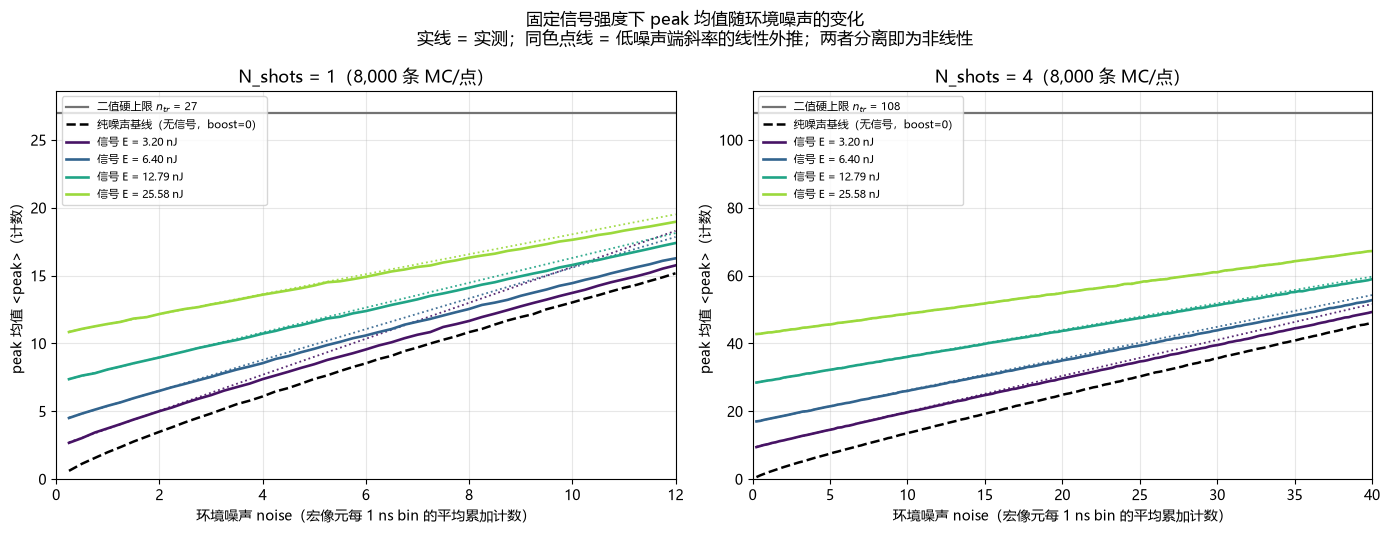

低噪声切线斜率 k = d<peak>/d(noise)（计数 / 单位 noise）：
  N_shots=1: E=3.20nJ → k=1.327，E=6.40nJ → k=1.133，E=12.79nJ → k=0.915，E=25.58nJ → k=0.736
  N_shots=4: E=3.20nJ → k=1.058，E=6.40nJ → k=0.937，E=12.79nJ → k=0.785，E=25.58nJ → k=0.619


In [2]:
LO_FRAC = 0.15   # 用前 15% 的 noise 量程拟合"低噪声切线"

def low_noise_tangent(x, y, lo_frac=LO_FRAC):
    '''用低噪声端做一次线性拟合，返回 (斜率, 截距)。'''
    m = x <= x[0] + lo_frac * (x[-1] - x[0])
    if m.sum() < 2:
        m = np.arange(len(x)) < 2
    k, b = np.polyfit(x[m], y[m], 1)
    return k, b

COLORS = plt.cm.viridis(np.linspace(0.05, 0.85, len(BOOSTS) - 1))
TANGENT = {}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.4))
for ax, n in zip(axes, N_LIST):
    d, st = DATA[n], STAT[n]
    x = d["noise"]
    TANGENT[n] = {}
    ax.axhline(d["n_tr"], color="0.45", lw=1.6,
               label=f"二值硬上限 $n_{{tr}}$ = {d['n_tr']}")
    ax.plot(x, st["mean"][0], "k--", lw=1.8,
            label="纯噪声基线（无信号，boost=0）")
    for i in range(1, len(BOOSTS)):
        y = st["mean"][i]
        c = COLORS[i - 1]
        ax.plot(x, y, "-", color=c, lw=1.9,
                label=f"信号 E = {E_NJ[i]:.2f} nJ")
        k, b = low_noise_tangent(x, y)
        TANGENT[n][i] = (k, b)
        ax.plot(x, k * x + b, ":", color=c, lw=1.3, alpha=0.9)
    ax.set_xlabel("环境噪声 noise（宏像元每 1 ns bin 的平均累加计数）")
    ax.set_ylabel("peak 均值 <peak>（计数）")
    ax.set_title(f"N_shots = {n}（{N_MC:,} 条 MC/点）")
    ax.set_xlim(0, x[-1]); ax.set_ylim(0, d["n_tr"] * 1.06)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc="upper left", ncol=1)
fig.suptitle("固定信号强度下 peak 均值随环境噪声的变化\n"
             "实线 = 实测；同色点线 = 低噪声端斜率的线性外推；"
             "两者分离即为非线性", fontsize=12)
fig.tight_layout()
plt.show()

print("低噪声切线斜率 k = d<peak>/d(noise)（计数 / 单位 noise）：")
for n in N_LIST:
    print(f"  N_shots={n}: " + "，".join(
        f"E={E_NJ[i]:.2f}nJ → k={TANGENT[n][i][0]:.3f}"
        for i in range(1, len(BOOSTS))))

## 模块 2：线性性的定量判定

三个判据，**层次不同，别混为一谈**：

1. **曲线自身的弯曲程度** —— 局部斜率
   $k(\text{noise}) = \dfrac{\mathrm{d}\langle \text{peak}\rangle}{\mathrm{d}\,\text{noise}}$。
   严格线性 ⇔ 该曲线是一条水平线。
2. **相对线性外推的偏差**
   $\dfrac{\langle \text{peak}\rangle_{\text{实测}} - (k_0\cdot \text{noise} + b_0)}{n_{tr}}\times 100\%$，
   其中 $k_0, b_0$ 是模块 1 的低噪声切线。用硬上限 $n_{tr}$ 归一，使 N=1 与 N=4 可比。
3. **可分离性（信号与噪声能否线性叠加）** —— 这是最关键、也最容易被前两个判据掩盖的一条。
   假设 peak 可以写成"信号项 + 噪声项"：

$$\langle \text{peak}\rangle \;=\; f(\text{信号}) \;+\; g(\text{noise})$$

   那么必然有 $\dfrac{\partial \langle \text{peak}\rangle}{\partial\,\text{noise}} = g'(\text{noise})$，
   **与信号强度完全无关**。所以只要实测发现"斜率随信号强度变化"，
   就**直接否定了线性叠加**，无论单条曲线看起来多直。

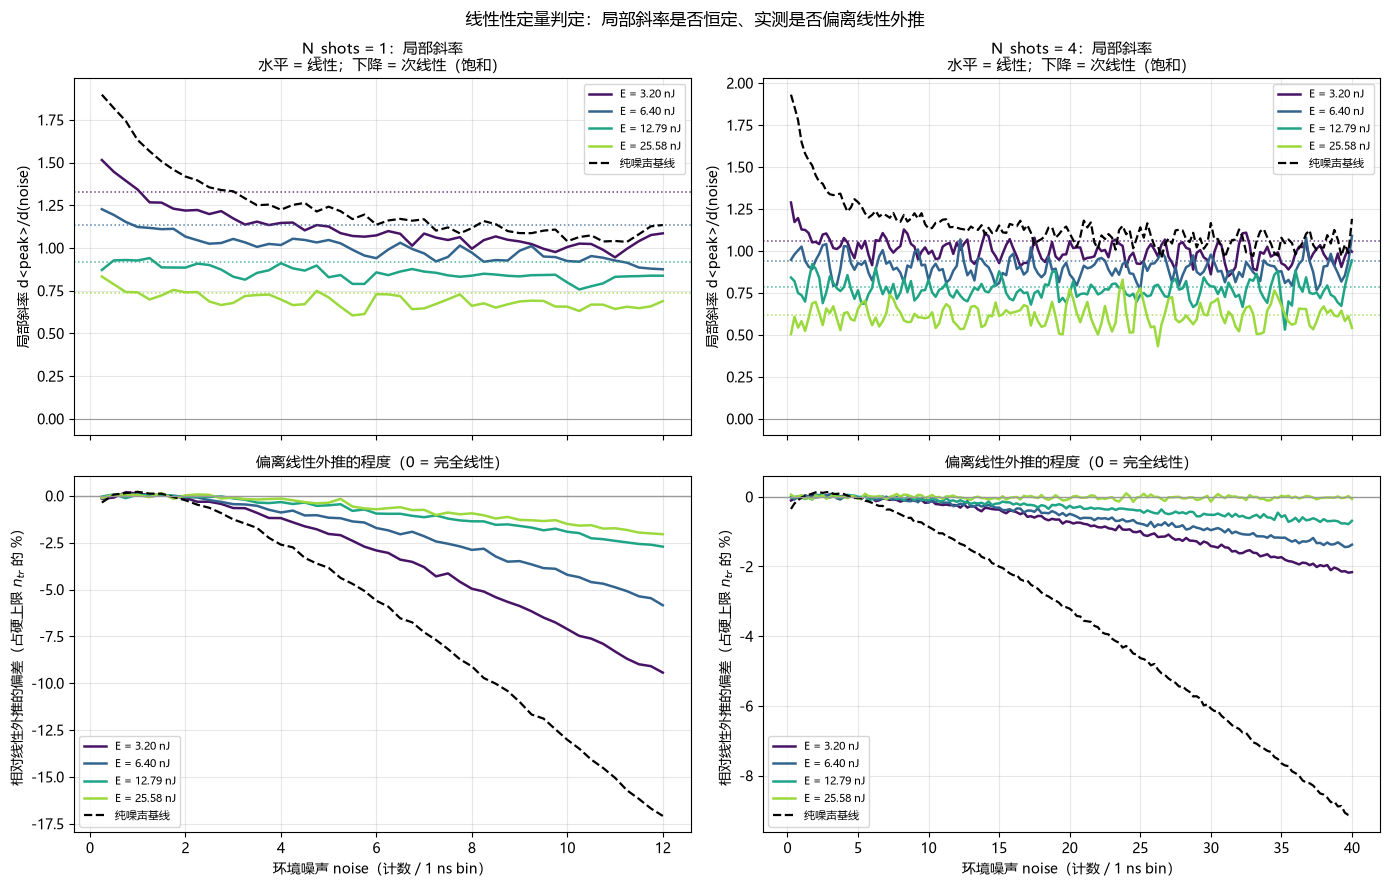

判据 1+2：单条曲线的弯曲程度（* 行为纯噪声基线，即无信号）
  N    E [nJ]       k0    k_end  k_end/k0     最大偏差[%n_tr]      全程线性R2
  1    0.00 *    1.624    1.084      0.67           -17.1      0.9966
  1      3.20    1.327    1.028      0.78            -9.4      0.9984
  1      6.40    1.133    0.896      0.79            -5.8      0.9992
  1     12.79    0.915    0.835      0.91            -2.7      0.9997
  1     25.58    0.736    0.659      0.90            -2.0      0.9997
  4    0.00 *    1.385    1.050      0.76            -9.2      0.9989
  4      3.20    1.058    0.973      0.92            -2.2      0.9999
  4      6.40    0.937    0.914      0.98            -1.4      0.9999
  4     12.79    0.785    0.794      1.01            -0.8      1.0000
  4     25.58    0.619    0.598      0.97            -0.1      1.0000

判据 3：可分离性 —— 斜率 ∂<peak>/∂noise 是否随信号强度变化
（若 <peak> = f(信号) + g(noise) 可线性叠加，同一 N 下这一列必须是常数）
  N    信号 E [nJ]   k0 = ∂<peak>/∂noise        相对无信号时
  1       0（无信号）                 1.624          100

In [3]:
def local_slope(x, y, win=5):
    '''滑动窗口最小二乘的局部斜率，比裸中心差分平滑（MC 噪声较大时更可读）。'''
    k = np.full_like(y, np.nan, dtype=float)
    h = win // 2
    for i in range(len(x)):
        a, b = max(0, i - h), min(len(x), i + h + 1)
        if b - a >= 2:
            k[i] = np.polyfit(x[a:b], y[a:b], 1)[0]
    return k

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex="col")
for j, n in enumerate(N_LIST):
    d, st = DATA[n], STAT[n]
    x = d["noise"]

    ax = axes[0, j]
    for i in range(1, len(BOOSTS)):
        c = COLORS[i - 1]
        ks = local_slope(x, st["mean"][i])
        ax.plot(x, ks, "-", color=c, lw=1.8, label=f"E = {E_NJ[i]:.2f} nJ")
        ax.axhline(TANGENT[n][i][0], color=c, ls=":", lw=1.1, alpha=0.8)
    ax.plot(x, local_slope(x, st["mean"][0]), "k--", lw=1.6,
            label="纯噪声基线")
    ax.axhline(0, color="0.6", lw=0.8)
    ax.set_ylabel("局部斜率 d<peak>/d(noise)")
    ax.set_title(f"N_shots = {n}：局部斜率\n"
                 "水平 = 线性；下降 = 次线性（饱和）", fontsize=11)
    ax.grid(alpha=0.3); ax.legend(fontsize=8)

    ax = axes[1, j]
    for i in range(1, len(BOOSTS)):
        k0, b0 = TANGENT[n][i]
        dev = (st["mean"][i] - (k0 * x + b0)) / d["n_tr"] * 100.0
        ax.plot(x, dev, "-", color=COLORS[i - 1], lw=1.8,
                label=f"E = {E_NJ[i]:.2f} nJ")
    k0, b0 = low_noise_tangent(x, st["mean"][0])
    ax.plot(x, (st["mean"][0] - (k0 * x + b0)) / d["n_tr"] * 100.0,
            "k--", lw=1.6, label="纯噪声基线")
    ax.axhline(0, color="0.6", lw=1.0)
    ax.set_xlabel("环境噪声 noise（计数 / 1 ns bin）")
    ax.set_ylabel("相对线性外推的偏差（占硬上限 $n_{tr}$ 的 %）")
    ax.set_title("偏离线性外推的程度（0 = 完全线性）", fontsize=11)
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
fig.suptitle("线性性定量判定：局部斜率是否恒定、实测是否偏离线性外推", fontsize=12)
fig.tight_layout()
plt.show()

SLOPE0 = {}          # 低噪声斜率 k0，供判据 3 用
print("=" * 104)
print("判据 1+2：单条曲线的弯曲程度（* 行为纯噪声基线，即无信号）")
print(f"{'N':>3}{'E [nJ]':>10}{'k0':>9}{'k_end':>9}{'k_end/k0':>10}"
      f"{'最大偏差[%n_tr]':>16}{'全程线性R2':>12}")
for n in N_LIST:
    d, st = DATA[n], STAT[n]
    x = d["noise"]
    SLOPE0[n] = []
    for i in range(len(BOOSTS)):
        y = st["mean"][i]
        k0, b0 = (TANGENT[n][i] if i else low_noise_tangent(x, y))
        SLOPE0[n].append(k0)
        k_end = np.nanmean(local_slope(x, y)[-5:])
        dev = (y - (k0 * x + b0)) / d["n_tr"] * 100.0
        kf, bf = np.polyfit(x, y, 1)
        ss_res = ((y - (kf * x + bf)) ** 2).sum()
        ss_tot = ((y - y.mean()) ** 2).sum()
        r2 = 1 - ss_res / max(ss_tot, 1e-12)
        tag = "0.00 *" if i == 0 else f"{E_NJ[i]:.2f}"
        print(f"{n:>3}{tag:>10}{k0:>9.3f}{k_end:>9.3f}"
              f"{k_end/k0:>10.2f}{dev.min():>16.1f}{r2:>12.4f}")

print()
print("=" * 104)
print("判据 3：可分离性 —— 斜率 ∂<peak>/∂noise 是否随信号强度变化")
print("（若 <peak> = f(信号) + g(noise) 可线性叠加，同一 N 下这一列必须是常数）")
print(f"{'N':>3}{'信号 E [nJ]':>13}{'k0 = ∂<peak>/∂noise':>22}"
      f"{'相对无信号时':>14}")
for n in N_LIST:
    for i in range(len(BOOSTS)):
        tag = "0（无信号）" if i == 0 else f"{E_NJ[i]:.2f}"
        print(f"{n:>3}{tag:>13}{SLOPE0[n][i]:>22.3f}"
              f"{SLOPE0[n][i]/SLOPE0[n][0]*100:>13.0f}%")
    drop = (1 - SLOPE0[n][-1] / SLOPE0[n][0]) * 100
    print(f"    → N_shots={n}：信号从 0 加到 {E_NJ[-1]:.2f} nJ，"
          f"噪声的边际贡献下降 {drop:.0f}%，"
          f"{'可分离性被否定' if drop > 5 else '近似可分离'}")

## 模块 3：信号的净增量 —— 噪声"吃掉"了多少信号

把 peak 拆开看：

$$\Delta(\text{noise}) \;=\; \langle \text{peak}\rangle_{\text{信号}+\text{噪声}} \;-\; \langle \text{peak}\rangle_{\text{纯噪声}}$$

$\Delta$ 就是**信号相对噪声本底的净抬升**，也就是检测真正能用上的那部分。

如果信号与噪声是简单相加（线性叠加），$\Delta$ 应当**与 noise 无关**（水平线）。
右图用 noise = 0 的纯信号 peak 作分母归一化：

$$\text{可加性比} \;=\; \frac{\Delta(\text{noise})}{\langle\text{peak}\rangle_{\text{纯信号, noise}=0}}$$

- 等于 1 ⇒ 严格可加（线性叠加）
- 小于 1 ⇒ **次可加（sub-additive）**：噪声先占用了 SPAD，信号来时已无 SPAD 可触发

物理机制：每个 SPAD 在一个 bin 内最多计 1 次，且雪崩后要经历 RC 恢复
（τ_RC = 8.73 ns，过阈窗宽 T_OVER ≈ 8 ns）。噪声光子先到就会"抢占"该 SPAD，
使它在信号到来时处于恢复期而无法响应。这是一种**竞争/抢占**关系，不是相加关系。

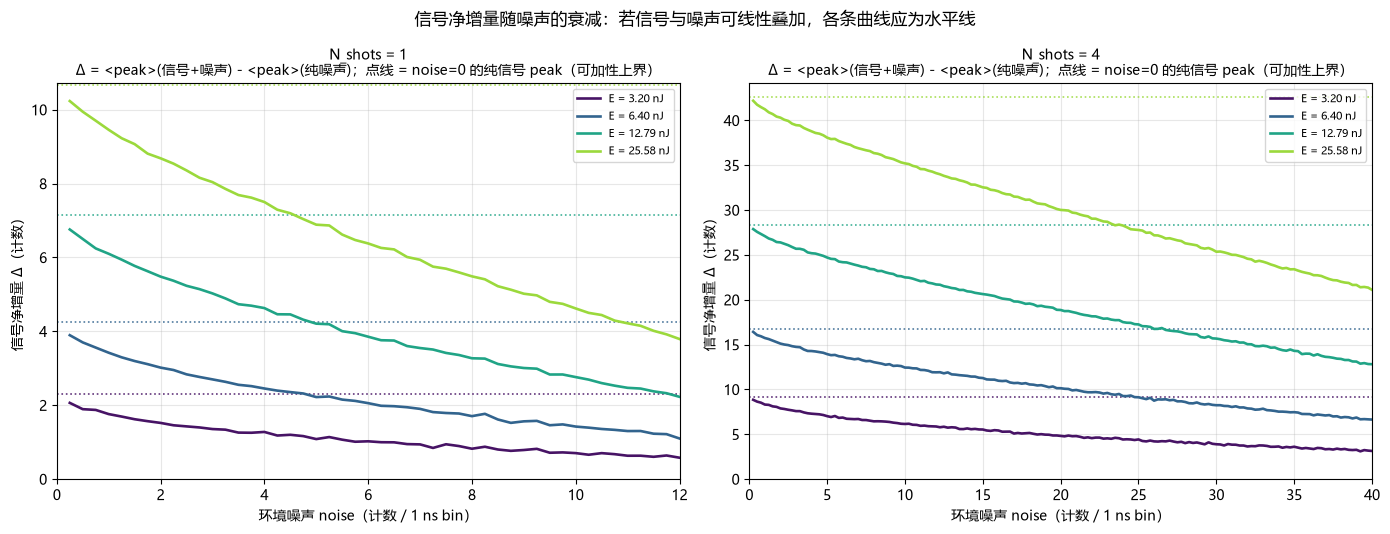

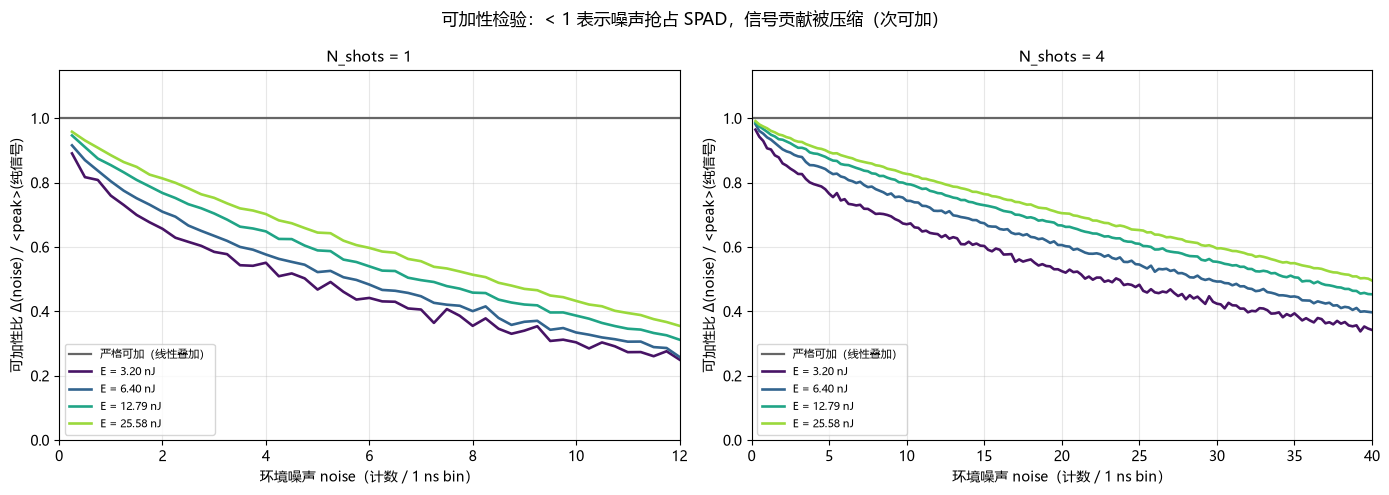

信号净增量 Δ 的衰减（Δ 相对 noise=0 纯信号 peak 的比值）
  N   E [nJ]    纯信号peak    Δ@最低noise      Δ@半量程    Δ@最高noise      末端保留
  1     3.20       2.32         2.06       1.00         0.58       25%
  1     6.40       4.25         3.90       1.99         1.10       26%
  1    12.79       7.14         6.76       3.76         2.23       31%
  1    25.58      10.68        10.24       6.26         3.79       36%
  4     3.20       9.17         8.85       4.77         3.14       34%
  4     6.40      16.73        16.42      10.08         6.64       40%
  4    12.79      28.28        27.88      18.74        12.82       45%
  4    25.58      42.58        42.20      29.99        21.11       50%


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.4))
for ax, n in zip(axes, N_LIST):
    d, st = DATA[n], STAT[n]
    x = d["noise"]
    for i in range(1, len(BOOSTS)):
        delta = st["mean"][i] - st["mean"][0]
        ax.plot(x, delta, "-", color=COLORS[i - 1], lw=1.9,
                label=f"E = {E_NJ[i]:.2f} nJ")
        ax.axhline(st["mean0"][i], color=COLORS[i - 1], ls=":", lw=1.2,
                   alpha=0.85)
    ax.set_xlabel("环境噪声 noise（计数 / 1 ns bin）")
    ax.set_ylabel("信号净增量 Δ（计数）")
    ax.set_title(f"N_shots = {n}\n"
                 "Δ = <peak>(信号+噪声) - <peak>(纯噪声)；"
                 "点线 = noise=0 的纯信号 peak（可加性上界）", fontsize=10)
    ax.set_xlim(0, x[-1]); ax.set_ylim(bottom=0)
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
fig.suptitle("信号净增量随噪声的衰减：若信号与噪声可线性叠加，各条曲线应为水平线",
             fontsize=12)
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.0))
for ax, n in zip(axes, N_LIST):
    d, st = DATA[n], STAT[n]
    x = d["noise"]
    ax.axhline(1.0, color="0.4", lw=1.6, label="严格可加（线性叠加）")
    for i in range(1, len(BOOSTS)):
        ratio = (st["mean"][i] - st["mean"][0]) / st["mean0"][i]
        ax.plot(x, ratio, "-", color=COLORS[i - 1], lw=1.9,
                label=f"E = {E_NJ[i]:.2f} nJ")
    ax.set_xlabel("环境噪声 noise（计数 / 1 ns bin）")
    ax.set_ylabel("可加性比 Δ(noise) / <peak>(纯信号)")
    ax.set_title(f"N_shots = {n}", fontsize=11)
    ax.set_xlim(0, x[-1]); ax.set_ylim(0, 1.15)
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
fig.suptitle("可加性检验：< 1 表示噪声抢占 SPAD，信号贡献被压缩（次可加）",
             fontsize=12)
fig.tight_layout()
plt.show()

print("=" * 96)
print("信号净增量 Δ 的衰减（Δ 相对 noise=0 纯信号 peak 的比值）")
print(f"{'N':>3}{'E [nJ]':>9}{'纯信号peak':>11}"
      f"{'Δ@最低noise':>13}{'Δ@半量程':>11}{'Δ@最高noise':>13}{'末端保留':>10}")
for n in N_LIST:
    d, st = DATA[n], STAT[n]
    x, mid = d["noise"], len(d["noise"]) // 2
    for i in range(1, len(BOOSTS)):
        dl = st["mean"][i] - st["mean"][0]
        print(f"{n:>3}{E_NJ[i]:>9.2f}{st['mean0'][i]:>11.2f}"
              f"{dl[0]:>13.2f}{dl[mid]:>11.2f}{dl[-1]:>13.2f}"
              f"{dl[-1]/st['mean0'][i]*100:>9.0f}%")

## 模块 4：分布形状怎么变

前面只看均值。这里直接画 **peak 的概率质量分布**（缓存里存的就是 `bincount`，
所以这是完整分布，不是拟合）。

每个子图对应一个 noise 档，图中同时画出纯噪声分布（灰色填充）与各信号档分布。
关注三件事：分布**往哪挪**、**变宽还是变窄**、与纯噪声分布**是否还分得开**。

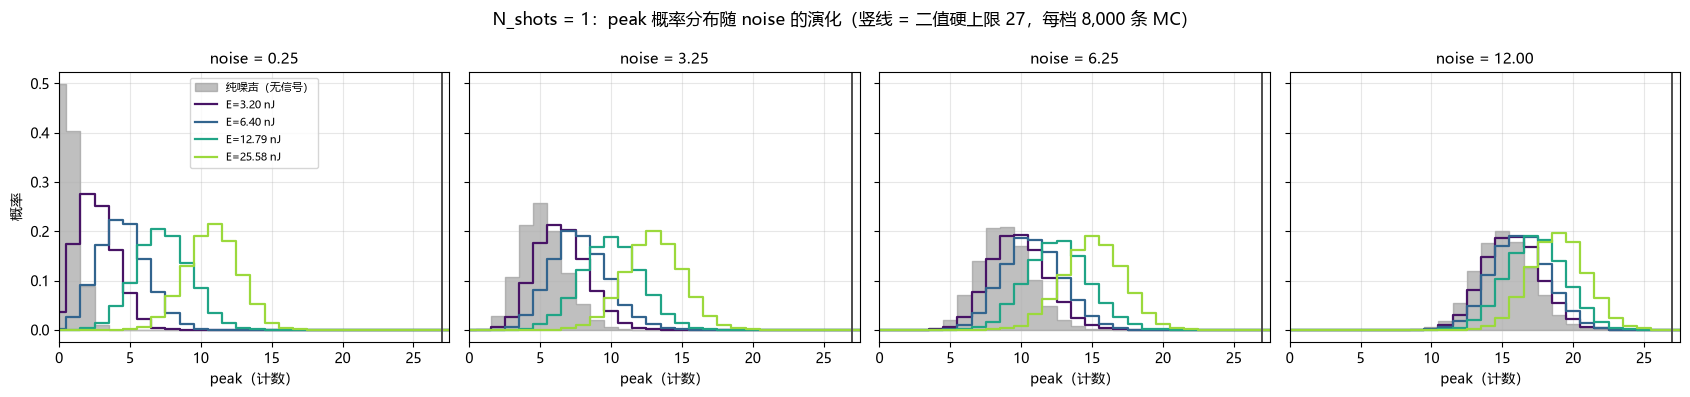

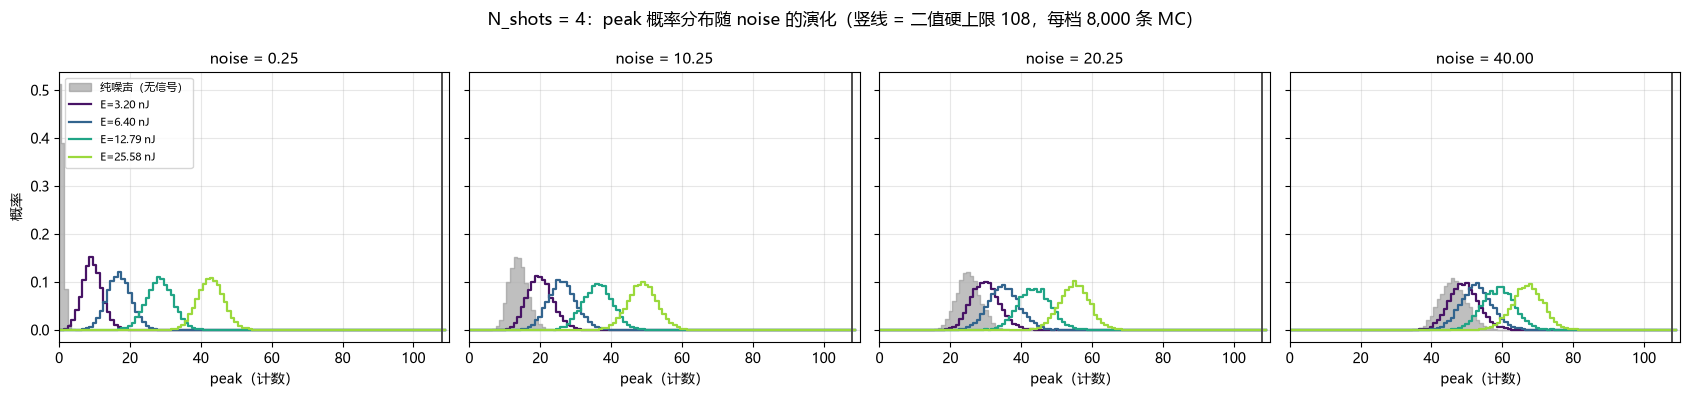

In [5]:
for n in N_LIST:
    d = DATA[n]
    x = d["noise"]
    picks = [0, len(x) // 4, len(x) // 2, len(x) - 1]
    fig, axes = plt.subplots(1, 4, figsize=(17, 4.0), sharey=True)
    for ax, k in zip(axes, picks):
        v = np.arange(d["cnt"].shape[-1])
        pmf_n = bc_pmf(d["cnt"][0, k])
        ax.fill_between(v, 0, pmf_n, color="0.55", alpha=0.55, step="mid",
                        label="纯噪声（无信号）")
        for i in range(1, len(BOOSTS)):
            ax.step(v, bc_pmf(d["cnt"][i, k]), where="mid",
                    color=COLORS[i - 1], lw=1.6, label=f"E={E_NJ[i]:.2f} nJ")
        ax.axvline(d["n_tr"], color="0.3", lw=1.4)
        ax.set_xlim(0, d["n_tr"] * 1.02)
        ax.set_xlabel("peak（计数）")
        ax.set_title(f"noise = {x[k]:.2f}", fontsize=11)
        ax.grid(alpha=0.3)
    axes[0].set_ylabel("概率")
    axes[0].legend(fontsize=8)
    fig.suptitle(f"N_shots = {n}：peak 概率分布随 noise 的演化"
                 f"（竖线 = 二值硬上限 {d['n_tr']}，每档 {N_MC:,} 条 MC）",
                 fontsize=12)
    fig.tight_layout()
    plt.show()

## 模块 5：分布宽度与可分辨性

- **左图**：peak 的标准差 σ 随 noise 的变化。
- **右图**：信号档与纯噪声档的**可分辨度** $d'$（判别力指标，越大越好分开）：

$$d' \;=\; \frac{\langle \text{peak}\rangle_{s+n} - \langle \text{peak}\rangle_{n}}
{\sqrt{\left(\sigma_{s+n}^2 + \sigma_{n}^2\right)/2}}$$

$d'$ 同时包含了"信号净增量被压缩"和"分布变宽"两种劣化，
比单看均值更能说明**检测**层面的实际后果。

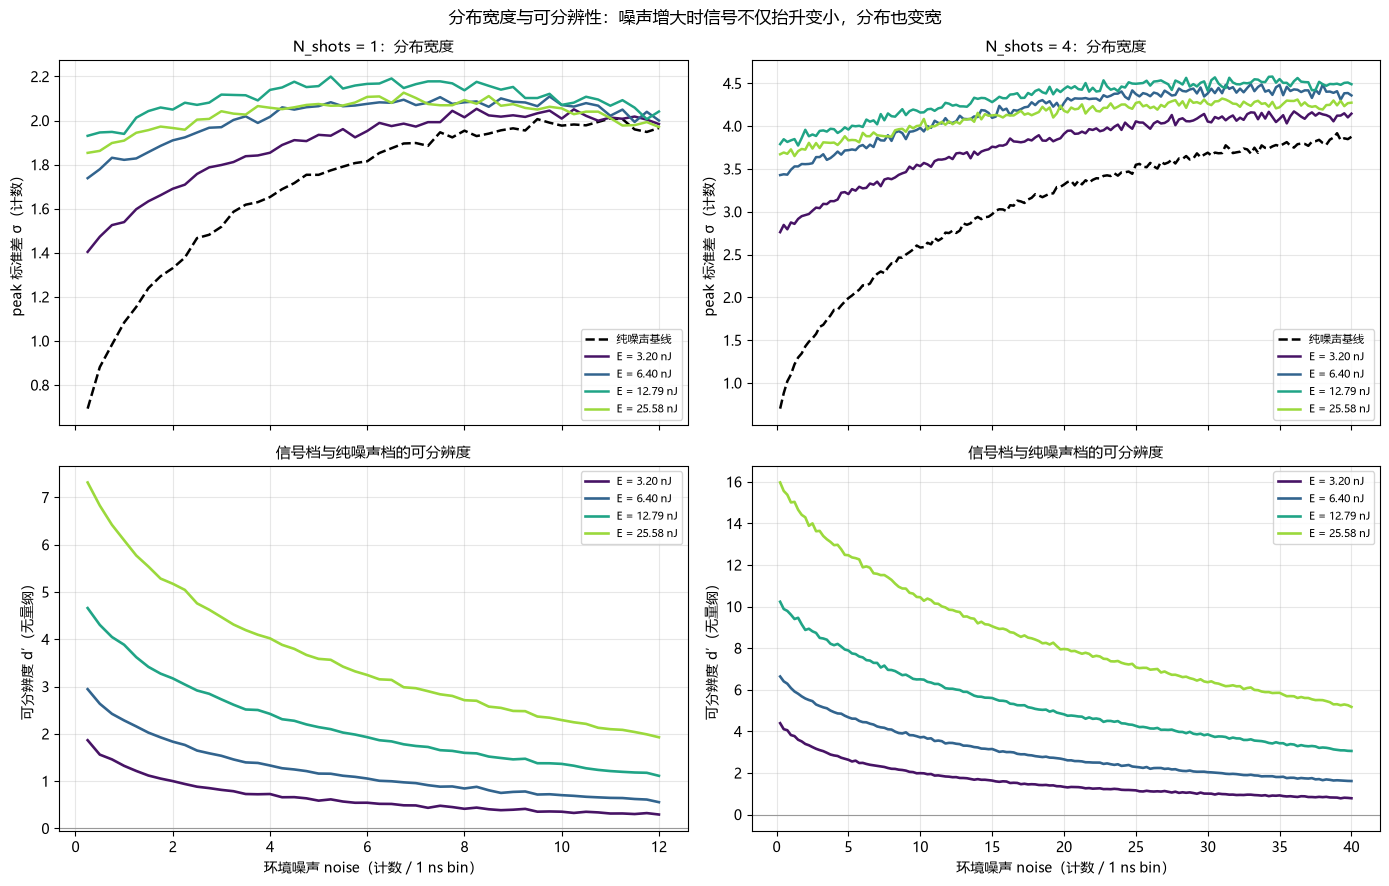

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex="col")
for j, n in enumerate(N_LIST):
    d, st = DATA[n], STAT[n]
    x = d["noise"]

    ax = axes[0, j]
    ax.plot(x, st["std"][0], "k--", lw=1.8, label="纯噪声基线")
    for i in range(1, len(BOOSTS)):
        ax.plot(x, st["std"][i], "-", color=COLORS[i - 1], lw=1.8,
                label=f"E = {E_NJ[i]:.2f} nJ")
    ax.set_ylabel("peak 标准差 σ（计数）")
    ax.set_title(f"N_shots = {n}：分布宽度", fontsize=11)
    ax.grid(alpha=0.3); ax.legend(fontsize=8)

    ax = axes[1, j]
    for i in range(1, len(BOOSTS)):
        dp = ((st["mean"][i] - st["mean"][0])
              / np.sqrt((st["std"][i] ** 2 + st["std"][0] ** 2) / 2))
        ax.plot(x, dp, "-", color=COLORS[i - 1], lw=1.9,
                label=f"E = {E_NJ[i]:.2f} nJ")
    ax.axhline(0, color="0.6", lw=0.8)
    ax.set_xlabel("环境噪声 noise（计数 / 1 ns bin）")
    ax.set_ylabel("可分辨度 d′（无量纲）")
    ax.set_title("信号档与纯噪声档的可分辨度", fontsize=11)
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
fig.suptitle("分布宽度与可分辨性：噪声增大时信号不仅抬升变小，分布也变宽", fontsize=12)
fig.tight_layout()
plt.show()

## 模块 6：分布带与检测阈值的关系

把 peak 的 1%–99% 分位带画出来，叠加 `PoD_esti_v05` 算出的 FAR 阈值曲线。
这一张图直接说明：随着 noise 增大，**阈值抬升的速度 vs 信号分布抬升的速度**谁更快
——两者交叉之处就是该信号强度"失守"的噪声水平。

阈值取 **FAR = 100 ppm** 与 **FAR = 10 ppm** 两档作代表（虚警率越低阈值越高）。

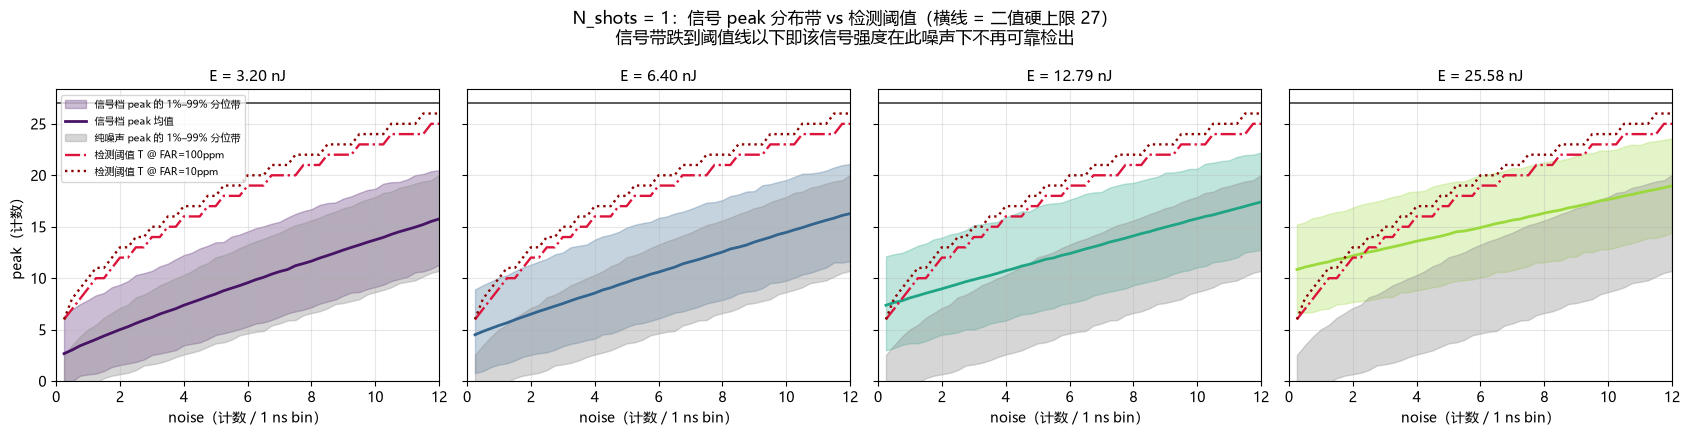

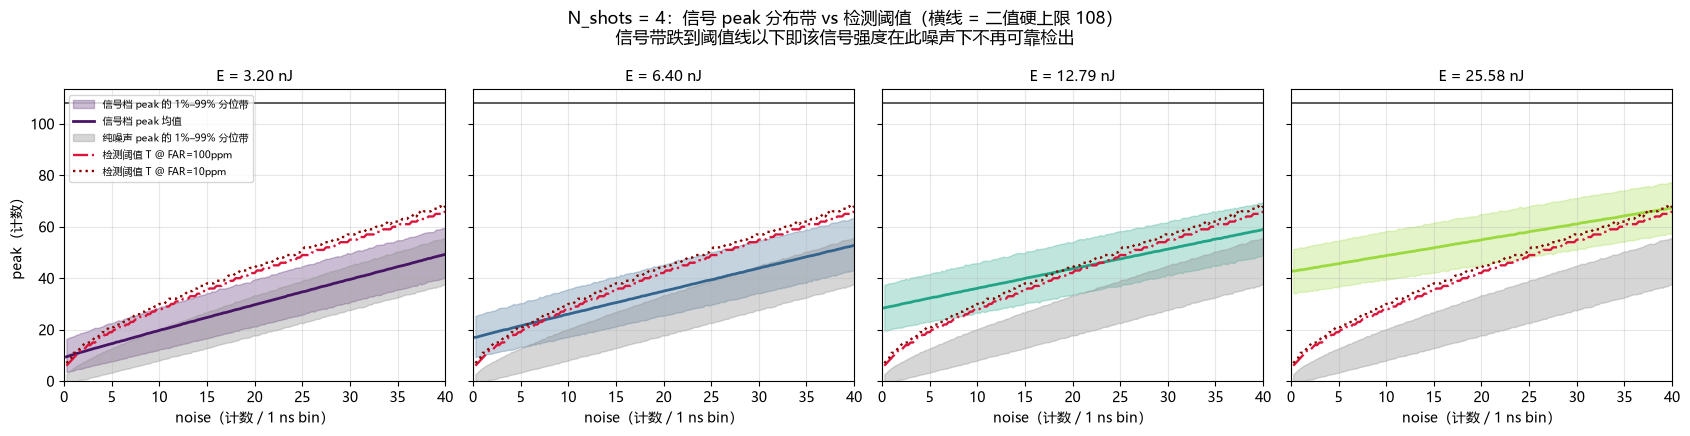

In [7]:
REF_TAGS = ["100ppm", "10ppm"]
TSTYLE = {"100ppm": ("-.", "crimson"), "10ppm": (":", "darkred")}

for n in N_LIST:
    d, st = DATA[n], STAT[n]
    x = d["noise"]
    fig, axes = plt.subplots(1, len(BOOSTS) - 1, figsize=(17, 4.4),
                             sharey=True)
    for ax, i in zip(np.atleast_1d(axes), range(1, len(BOOSTS))):
        p01 = np.array([bc_quantile(d["cnt"][i, k], 0.01) for k in range(len(x))])
        p99 = np.array([bc_quantile(d["cnt"][i, k], 0.99) for k in range(len(x))])
        ax.fill_between(x, p01, p99, color=COLORS[i - 1], alpha=0.28,
                        label="信号档 peak 的 1%–99% 分位带")
        ax.plot(x, st["mean"][i], "-", color=COLORS[i - 1], lw=2.0,
                label="信号档 peak 均值")
        n01 = np.array([bc_quantile(d["cnt"][0, k], 0.01) for k in range(len(x))])
        n99 = np.array([bc_quantile(d["cnt"][0, k], 0.99) for k in range(len(x))])
        ax.fill_between(x, n01, n99, color="0.55", alpha=0.35,
                        label="纯噪声 peak 的 1%–99% 分位带")
        for tag in REF_TAGS:
            ls, c = TSTYLE[tag]
            ax.plot(x, d["T"][FAR_TAGS.index(tag)], ls, color=c, lw=1.7,
                    label=f"检测阈值 T @ FAR={tag}")
        ax.axhline(d["n_tr"], color="0.3", lw=1.3)
        ax.set_xlabel("noise（计数 / 1 ns bin）")
        ax.set_title(f"E = {E_NJ[i]:.2f} nJ", fontsize=11)
        ax.set_xlim(0, x[-1]); ax.set_ylim(0, d["n_tr"] * 1.05)
        ax.grid(alpha=0.3)
    np.atleast_1d(axes)[0].set_ylabel("peak（计数）")
    np.atleast_1d(axes)[0].legend(fontsize=7.5, loc="upper left")
    fig.suptitle(f"N_shots = {n}：信号 peak 分布带 vs 检测阈值"
                 f"（横线 = 二值硬上限 {d['n_tr']}）\n"
                 "信号带跌到阈值线以下即该信号强度在此噪声下不再可靠检出",
                 fontsize=12)
    fig.tight_layout()
    plt.show()

## 结论

下面这段里所有数值和判定措辞都由**实测结果自动生成**（写死的只有物理机制的解释）。

先给答案：**不是线性的**，但要分两个层次说清楚——
单条 $\langle\text{peak}\rangle$–noise 曲线**看起来几乎是直线**，
真正的强非线性藏在"**信号与噪声不能相加**"这件事上。

In [8]:
print("=" * 100)
print("结论：固定信号强度下，peak 分布随 noise 增大的变化特征")
print("=" * 100)
for n in N_LIST:
    d, st = DATA[n], STAT[n]
    x = d["noise"]
    print(f"\n【N_shots = {n}，二值硬上限 n_tr = {d['n_tr']}，"
          f"noise 扫描 {x[0]:.2f} → {x[-1]:.2f}】")

    y0 = st["mean"][0]
    k0n, _ = low_noise_tangent(x, y0)
    kEn = np.nanmean(local_slope(x, y0)[-5:])
    print(f"  · 纯噪声基线：<peak> 从 {y0[0]:.2f} 升到 {y0[-1]:.2f}；"
          f"斜率由 {k0n:.3f} 降到 {kEn:.3f}（降为 {kEn/k0n*100:.0f}%）")

    for i in range(1, len(BOOSTS)):
        y = st["mean"][i]
        k0, b0 = TANGENT[n][i]
        kE = np.nanmean(local_slope(x, y)[-5:])
        dev = (y - (k0 * x + b0)) / d["n_tr"] * 100.0
        dl = y - y0
        keep = dl[-1] / st["mean0"][i] * 100.0
        dp0 = ((y[0] - y0[0])
               / np.sqrt((st["std"][i][0] ** 2 + st["std"][0][0] ** 2) / 2))
        dpE = ((y[-1] - y0[-1])
               / np.sqrt((st["std"][i][-1] ** 2 + st["std"][0][-1] ** 2) / 2))
        print(f"  · 信号 E = {E_NJ[i]:5.2f} nJ："
              f"<peak> {y[0]:.2f} → {y[-1]:.2f}；"
              f"斜率 {k0:.3f} → {kE:.3f}（{kE/k0*100:.0f}%）；"
              f"偏离线性外推最多 {dev.min():.1f}% n_tr")
        print(f"      信号净增量 Δ 由 {dl[0]:.2f} 降到 {dl[-1]:.2f}"
              f"（仅剩无噪声时的 {keep:.0f}%）；"
              f"可分辨度 d′ 由 {dp0:.2f} 降到 {dpE:.2f}")


# ---- 汇总三个判据的实测极值，用来自动生成判定措辞 ----
_r2_min, _dev_max, _sep_drop, _keep_min, _dp_ratio_min = 1.0, 0.0, {}, 100.0, 100.0
for n in N_LIST:
    d, st = DATA[n], STAT[n]
    x = d["noise"]
    for i in range(len(BOOSTS)):
        y = st["mean"][i]
        k0, b0 = (TANGENT[n][i] if i else low_noise_tangent(x, y))
        kf, bf = np.polyfit(x, y, 1)
        ss_res = ((y - (kf * x + bf)) ** 2).sum()
        ss_tot = ((y - y.mean()) ** 2).sum()
        _r2_min = min(_r2_min, 1 - ss_res / max(ss_tot, 1e-12))
        _dev_max = max(_dev_max, abs(((y - (k0 * x + b0)) / d["n_tr"] * 100).min()))
        if i:
            _keep_min = min(_keep_min, (y - st["mean"][0])[-1] / st["mean0"][i] * 100)
            dp0 = ((y[0] - st["mean"][0][0])
                   / np.sqrt((st["std"][i][0] ** 2 + st["std"][0][0] ** 2) / 2))
            dpE = ((y[-1] - st["mean"][0][-1])
                   / np.sqrt((st["std"][i][-1] ** 2 + st["std"][0][-1] ** 2) / 2))
            _dp_ratio_min = min(_dp_ratio_min, dpE / dp0 * 100)
    _sep_drop[n] = (1 - SLOPE0[n][-1] / SLOPE0[n][0]) * 100

print("\n" + "=" * 100)
print("总体结论")
print("=" * 100)
print(f'''
1) 先说容易被误判的一点：【单看 <peak> 对 noise 的曲线，它非常接近直线】。
   全程一次拟合的 R² 最低也有 {_r2_min:.4f}，偏离低噪声切线最多只有 {_dev_max:.1f}% n_tr。
   所以工程上用 <peak> ≈ a + b·noise 做估算是可行的近似。

2) 但【严格地说不是线性的，而是次线性（饱和型）】：局部斜率单调下降，
   曲线始终落在低噪声切线【下方】，并向二值硬上限 n_tr 渐近。
   弯曲最明显的是【弱信号 + N_shots=1】那一组（离硬上限最近）；
   信号越强、N_shots 越大，单条曲线反而越直。

3) 【真正的强非线性不在曲线形状上，而在"信号与噪声不可叠加"上】，两条独立证据：
   · 可分离性被否定：噪声的边际贡献 ∂<peak>/∂noise 明显依赖信号强度
     （N_shots=1 降 {_sep_drop[1]:.0f}%，N_shots=4 降 {_sep_drop[4]:.0f}%）。
     若 <peak> = f(信号) + g(noise)，这个斜率必须与信号强度无关。
   · 信号净增量 Δ 被持续压缩：到扫描末端只剩无噪声时的 {_keep_min:.0f}%–50%
     （若可线性叠加，Δ 应当与 noise 无关，是水平线）。

4) 机制（两条，叠加）：
   a. 【二值采样硬上限】：每个 SPAD 每 bin 至多 1 个计数，peak ≤ n_tr = 27 × N_shots，
      越接近上限增速越慢 —— 这解释了判据 2 的弯曲。
   b. 【死时间抢占】：噪声光子先触发某个 SPAD 后，该 SPAD 在 RC 恢复期
      （τ_RC = 8.73 ns，过阈窗 T_OVER ≈ 8 ns）内无法再响应信号光子。
      信号与噪声是在【竞争同一批 SPAD】，不是各自累加 —— 这解释了判据 3。

5) 分布形状不是简单平移：noise 增大时 peak 分布右移、展宽，
   同时信号档与纯噪声档的分布逐渐重叠。

6) 对检测的实际后果最严重：可分辨度 d′ 最差只剩低噪声时的 {_dp_ratio_min:.0f}%，
   衰减远比 <peak> 曲线"看上去很直"所暗示的要剧烈。
   叠加上 FAR 阈值本身也随 noise 抬升，两者相向而行，
   这正是 PoD_esti 中"临界能量随 noise 快速上升"的微观原因。
''')
print("=" * 100)

结论：固定信号强度下，peak 分布随 noise 增大的变化特征

【N_shots = 1，二值硬上限 n_tr = 27，noise 扫描 0.25 → 12.00】
  · 纯噪声基线：<peak> 从 0.61 升到 15.18；斜率由 1.624 降到 1.084（降为 67%）
  · 信号 E =  3.20 nJ：<peak> 2.68 → 15.76；斜率 1.327 → 1.028（78%）；偏离线性外推最多 -9.4% n_tr
      信号净增量 Δ 由 2.06 降到 0.58（仅剩无噪声时的 25%）；可分辨度 d′ 由 1.86 降到 0.29
  · 信号 E =  6.40 nJ：<peak> 4.51 → 16.28；斜率 1.133 → 0.896（79%）；偏离线性外推最多 -5.8% n_tr
      信号净增量 Δ 由 3.90 降到 1.10（仅剩无噪声时的 26%）；可分辨度 d′ 由 2.94 降到 0.55
  · 信号 E = 12.79 nJ：<peak> 7.37 → 17.40；斜率 0.915 → 0.835（91%）；偏离线性外推最多 -2.7% n_tr
      信号净增量 Δ 由 6.76 降到 2.23（仅剩无噪声时的 31%）；可分辨度 d′ 由 4.66 降到 1.11
  · 信号 E = 25.58 nJ：<peak> 10.85 → 18.97；斜率 0.736 → 0.659（90%）；偏离线性外推最多 -2.0% n_tr
      信号净增量 Δ 由 10.24 降到 3.79（仅剩无噪声时的 36%）；可分辨度 d′ 由 7.32 降到 1.93

【N_shots = 4，二值硬上限 n_tr = 108，noise 扫描 0.25 → 40.00】
  · 纯噪声基线：<peak> 从 0.60 升到 46.15；斜率由 1.385 降到 1.050（降为 76%）
  · 信号 E =  3.20 nJ：<peak> 9.45 → 49.29；斜率 1.058 → 0.973（92%）；偏离线性外推最多 -2.2% n_tr
      信号净增量 Δ 由 8.85 降到 3.14（仅剩无噪声时的 34%）；可分辨度 d′ 由 4.39 降到 0.78
  